In [ ]:
import pandas as pd
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from sklearn.datasets import fetch_openml
from sklearn.gaussian_process.kernels import RBF
from sklearn.gaussian_process.kernels import ExpSineSquared
from sklearn.gaussian_process.kernels import RationalQuadratic
from sklearn.gaussian_process.kernels import WhiteKernel
from sklearn.gaussian_process import GaussianProcessRegressor
import datetime

In [ ]:
co2 = fetch_openml(data_id=41187, as_frame = True)
co2.frame.head()

,year,month,day,weight,flag,station,co2
0,1958,3,29,4,0,MLO,316.1
1,1958,4,5,6,0,MLO,317.3
2,1958,4,12,4,0,MLO,317.6
3,1958,4,19,6,0,MLO,317.5
4,1958,4,26,2,0,MLO,316.4


In [4]:
co2_data = pl.DataFrame(co2.frame[['year','month','co2','day']]).select(pl.date('year','month','day'),'co2')
co2_data.head()

date,co2
date,f64
1958-03-29,316.1
1958-04-05,317.3
1958-04-12,317.6
1958-04-19,317.5
1958-04-26,316.4


In [5]:
co2_data['date'].min(), co2_data['date'].max()

(datetime.date(1958, 3, 29), datetime.date(2001, 12, 29))

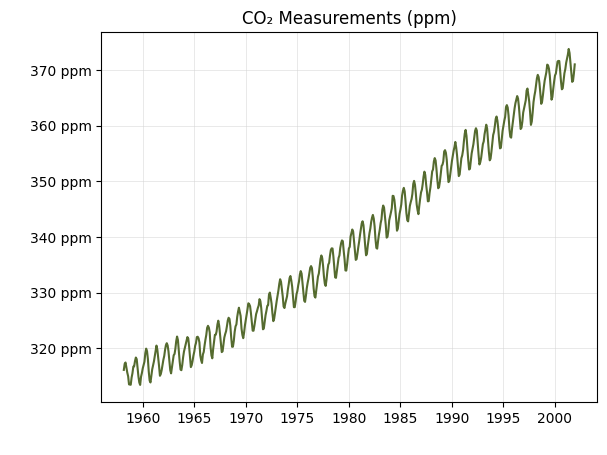

In [ ]:
plt.plot(co2_data['date'], co2_data['co2'], color = '#556b2f')
plt.title("CO₂ Measurements (ppm)")
plt.xlabel(" ")
plt.ylabel(" ")
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.0f} ppm'))
plt.grid(color='lightgrey', linestyle='-', linewidth=0.5, alpha=0.7)
plt.savefig("images/co2_measurements.png", dpi=300, bbox_inches="tight")
plt.show()

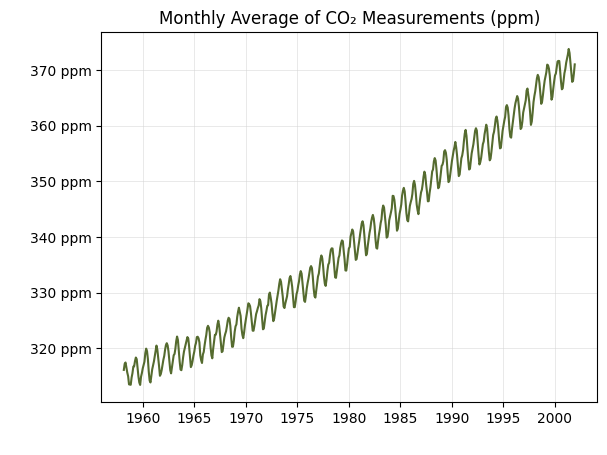

In [ ]:
co2_data = (co2_data.sort(by="date").group_by_dynamic("date", every="1mo").agg(pl.col("co2").mean()).drop_nulls())
plt.plot(co2_data["date"], co2_data["co2"], color = '#556b2f')
plt.xlabel(" ")
plt.ylabel(" ")
plt.title("Monthly Average of CO₂ Measurements (ppm)")
plt.grid(color='lightgrey', linestyle='-', linewidth=0.5, alpha=0.7)
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.0f} ppm'))
plt.savefig("images/monthly_co2_measurements.png", dpi=300, bbox_inches="tight")


In [ ]:
X = co2_data.select(pl.col("date").dt.year() + pl.col("date").dt.month() / 12).to_numpy()
y = co2_data["co2"].to_numpy()

In [ ]:
long_term_trend_kernel = 50.0**2 * RBF(length_scale=50.0)

In [ ]:
seasonal_kernel = (2.0**2* RBF(length_scale=100.0)* ExpSineSquared(length_scale=1.0, periodicity=1.0, periodicity_bounds="fixed"))

In [ ]:
irregularities_kernel = 0.5**2 * RationalQuadratic(length_scale=1.0, alpha=1.0)

In [ ]:
noise_kernel = 0.1**2 * RBF(length_scale=0.1) + WhiteKernel(noise_level=0.1**2, noise_level_bounds=(1e-5, 1e5))

In [ ]:
co2_kernel = (long_term_trend_kernel + seasonal_kernel + irregularities_kernel + noise_kernel)
co2_kernel

50**2 * RBF(length_scale=50) + 2**2 * RBF(length_scale=100) * ExpSineSquared(length_scale=1, periodicity=1) + 0.5**2 * RationalQuadratic(alpha=1, length_scale=1) + 0.1**2 * RBF(length_scale=0.1) + WhiteKernel(noise_level=0.01)

In [ ]:
y_mean = y.mean()
gaussian_process = GaussianProcessRegressor(kernel=co2_kernel, normalize_y=False)
gaussian_process.fit(X, y - y_mean)

/Users/andreacaceres/Library/Python/3.9/lib/python/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__k2__k1__k1__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/andreacaceres/Library/Python/3.9/lib/python/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__k2__k1__k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/andreacaceres/Library/Python/3.9/lib/python/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__k2__k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better 

GaussianProcessRegressor(kernel=50**2 * RBF(length_scale=50) + 2**2 * RBF(length_scale=100) * ExpSineSquared(length_scale=1, periodicity=1) + 0.5**2 * RationalQuadratic(alpha=1, length_scale=1) + 0.1**2 * RBF(length_scale=0.1) + WhiteKernel(noise_level=0.01))

In [ ]:
today = datetime.datetime.now()
current_month = today.year + today.month / 12
X_test = np.linspace(start=1958, stop=current_month, num=1_000).reshape(-1, 1)
mean_y_pred, std_y_pred = gaussian_process.predict(X_test, return_std=True)
mean_y_pred += y_mean

/Users/andreacaceres/Library/Python/3.9/lib/python/site-packages/sklearn/gaussian_process/_gpr.py:441: RuntimeWarning: divide by zero encountered in matmul
  y_mean = K_trans @ self.alpha_
/Users/andreacaceres/Library/Python/3.9/lib/python/site-packages/sklearn/gaussian_process/_gpr.py:441: RuntimeWarning: overflow encountered in matmul
  y_mean = K_trans @ self.alpha_
/Users/andreacaceres/Library/Python/3.9/lib/python/site-packages/sklearn/gaussian_process/_gpr.py:441: RuntimeWarning: invalid value encountered in matmul
  y_mean = K_trans @ self.alpha_


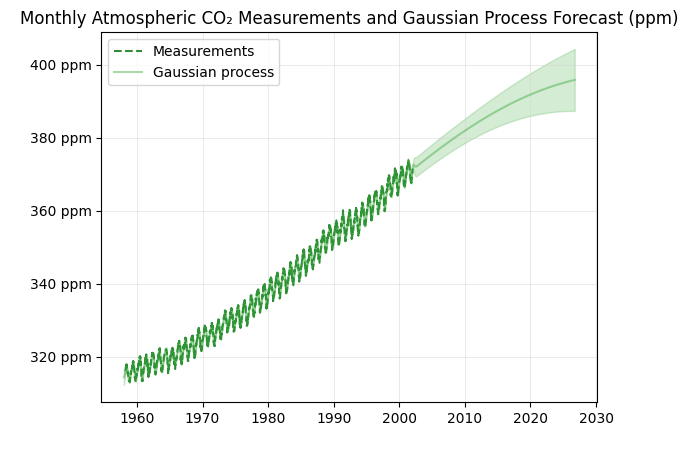

In [ ]:
plt.plot(X, y, color="#2F8F38", linestyle="dashed", label="Measurements")
plt.plot(X_test, mean_y_pred, color="tab:green", alpha=0.4, label="Gaussian process")
plt.fill_between(X_test.ravel(),mean_y_pred - std_y_pred,mean_y_pred + std_y_pred, color="tab:green", alpha=0.2,)
plt.legend()
plt.xlabel(" ")
plt.ylabel(" ")
plt.title("Monthly Atmospheric CO₂ Measurements and Gaussian Process Forecast (ppm)")
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.0f} ppm'))
plt.grid(color='lightgrey', linestyle='-', linewidth=0.5, alpha=0.7)
plt.savefig("images/gaussian_monthly_co2_measurements.png", dpi=300, bbox_inches="tight")
plt.show()
